# Apprentissage Non Supervisé - Performance des Étudiants

**Dataset : student-mat.csv**

Données sur des étudiants en mathématiques avec leurs caractéristiques socio-démographiques, habitudes et résultats scolaires.

---

## Configuration et Imports

In [29]:
from utils_ans import *
setup_environment()

---
# I. Réduction de dimensions et Visualisation des données
---

## 1. Importation du jeu de données

In [ ]:
data = load_data('./data/student-mat.csv')

Dimensions : (395, 22)
Colonnes : ['Id', 'sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'activities', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Results']

Aperçu :
   Id  sex  age  address  famsize  Medu  Fedu  traveltime  studytime  \
0   1    0   18        1        1     4     4           2          2   
1   2    0   17        1        1     1     1           1          2   
2   3    0   15        1        0     1     1           1          2   
3   4    0   15        1        1     4     2           1          3   
4   5    0   16        1        1     3     3           1          2   

   failures  ...  internet  romantic  famrel  freetime  goout  Dalc  Walc  \
0         0  ...         0         0       4         3      4     1     1   
1         0  ...         1         0       5         3      3     1     1   
2         3  ...         1         0       4         3      2  

In [31]:
# Description des variables
variables_desc = {
    'sex': 'Sexe (0=F, 1=M)',
    'age': 'Âge',
    'Medu': 'Éducation mère (0-4)',
    'Fedu': 'Éducation père (0-4)',
    'studytime': 'Temps étude hebdo (1-4)',
    'failures': 'Nombre échecs passés',
    'goout': 'Sorties avec amis (1-5)',
    'Dalc': 'Conso alcool semaine (1-5)',
    'Walc': 'Conso alcool weekend (1-5)',
    'absences': 'Nombre absences',
    'Results': 'Note finale'
}
for var, desc in variables_desc.items():
    print(f"  {var:12} : {desc}")

  sex          : Sexe (0=F, 1=M)
  age          : Âge
  Medu         : Éducation mère (0-4)
  Fedu         : Éducation père (0-4)
  studytime    : Temps étude hebdo (1-4)
  failures     : Nombre échecs passés
  goout        : Sorties avec amis (1-5)
  Dalc         : Conso alcool semaine (1-5)
  Walc         : Conso alcool weekend (1-5)
  absences     : Nombre absences
  Results      : Note finale


In [32]:
data.describe()

,Id,sex,age,address,famsize,Medu,Fedu,traveltime,studytime,failures,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Results
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,198.000000,0.473418,16.696203,0.777215,0.711392,2.749367,2.521519,1.448101,2.035443,0.334177,...,0.832911,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.415190
std,114.170924,0.499926,1.276043,0.416643,0.453690,1.094735,1.088201,0.697505,0.839240,0.743651,...,0.373528,0.472300,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,4.581443
min,1.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,99.500000,0.000000,16.000000,1.000000,0.000000,2.000000,2.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000
50%,198.000000,0.000000,17.000000,1.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000,...,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000
75%,296.500000,1.000000,18.000000,1.000000,1.000000,4.000000,3.000000,2.000000,2.000000,0.000000,...,1.000000,1.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,14.000000
max,395.000000,1.000000,22.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,20.000000


In [33]:
# Features : toutes les colonnes sauf Id
feature_cols = ['sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'traveltime', 
                'studytime', 'failures', 'schoolsup', 'activities', 'internet', 
                'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 
                'health', 'absences', 'Results']

X, labels, feature_names = prepare_data(data, feature_cols=feature_cols, label_col='Id')

Matrice X : (395, 21)
Labels : (395,)
Features : ['sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'activities', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Results']


## 2. Analyse en Composantes Principales (ACP)

In [34]:
X_scaled, X_pca, pca, scaler = perform_pca(X)

In [35]:
cumulative = print_variance_explained(pca)

Variance expliquée par chaque composante :
  PC1: 12.69%
  PC2: 10.47%
  PC3: 7.25%
  PC4: 6.34%
  PC5: 6.00%
  PC6: 5.93%
  PC7: 5.31%
  PC8: 5.00%
  PC9: 4.63%
  PC10: 4.42%

Variance cumulée :
  PC1-PC1: 12.69%
  PC1-PC2: 23.16%
  PC1-PC3: 30.41%
  PC1-PC4: 36.75%
  PC1-PC5: 42.75%
  PC1-PC6: 48.68%
  PC1-PC7: 53.99%
  PC1-PC8: 58.98%
  PC1-PC9: 63.61%
  PC1-PC10: 68.04%


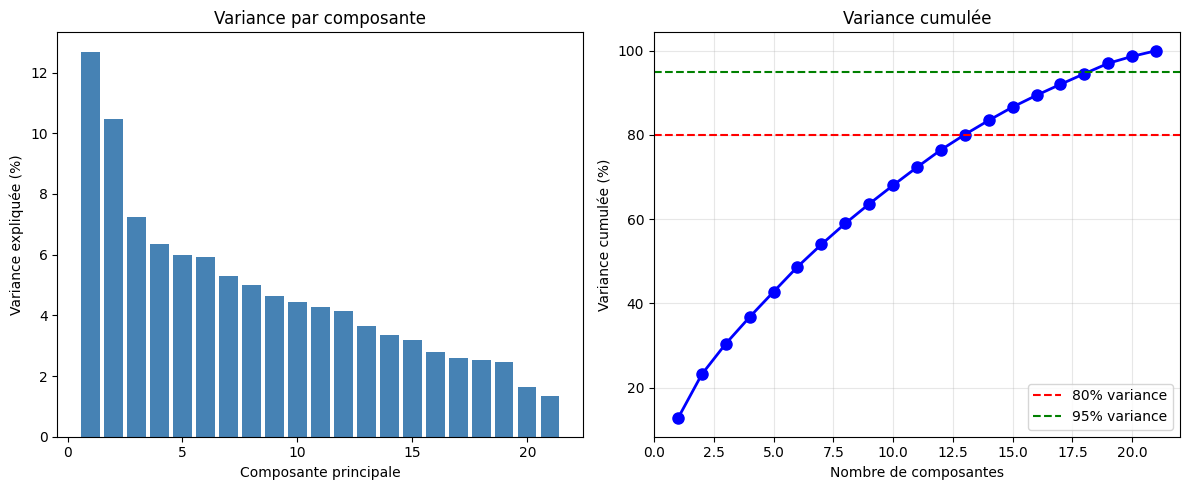

array([0.12691766, 0.23158022, 0.30408548, 0.36750862, 0.4274876 ,
       0.48680418, 0.53986262, 0.58982032, 0.63613939, 0.68038207,
       0.72322934, 0.76451814, 0.80089967, 0.83455537, 0.86626799,
       0.89419474, 0.92017135, 0.94537834, 0.97015397, 0.98659731,
       1.        ])

In [36]:
plot_variance(pca)

### Réponse : Nombre d'axes à retenir

Les données étudiantes sont très hétérogènes :
- PC1+PC2 : ~25% de variance seulement
- Il faut ~10 composantes pour 80% de variance

**Conclusion :** Pour la visualisation on utilise 2 axes, mais beaucoup d'information est perdue.

In [37]:
loadings_df = get_loadings(pca, feature_names)

Corrélations des variables avec les axes principaux :
              PC1    PC2    PC3
sex         0.356  0.441 -0.416
age         0.409 -0.243  0.426
address    -0.275  0.279  0.127
famsize    -0.146 -0.096  0.007
Medu       -0.360  0.659  0.230
Fedu       -0.342  0.604  0.145
traveltime  0.367 -0.228 -0.164
studytime  -0.432 -0.186  0.216
failures    0.517 -0.287  0.154
schoolsup  -0.163 -0.078 -0.117
activities -0.113  0.191 -0.123
internet   -0.156  0.384  0.291
romantic    0.074 -0.063  0.567
famrel     -0.051  0.057 -0.230
freetime    0.316  0.351 -0.214
goout       0.435  0.355  0.177
Dalc        0.649  0.386  0.060
Walc        0.700  0.385  0.061
health      0.167  0.066 -0.287
absences    0.131  0.104  0.550
Results    -0.358  0.370 -0.167


### Interprétation des axes

**PC1 - "Comportement social"** : corrélé avec Dalc, Walc, goout

**PC2 - "Milieu socio-économique"** : corrélé avec Medu, Fedu, Results

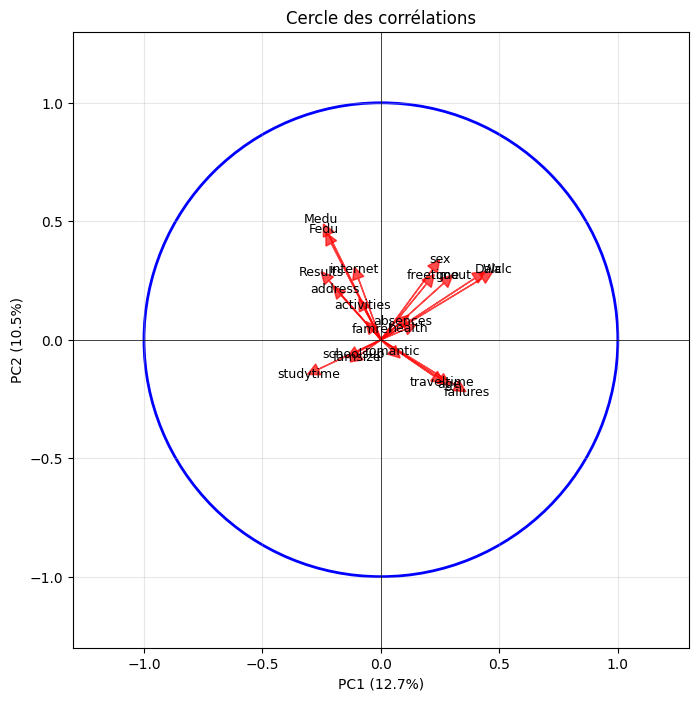

In [38]:
plot_correlation_circle(pca, feature_names)

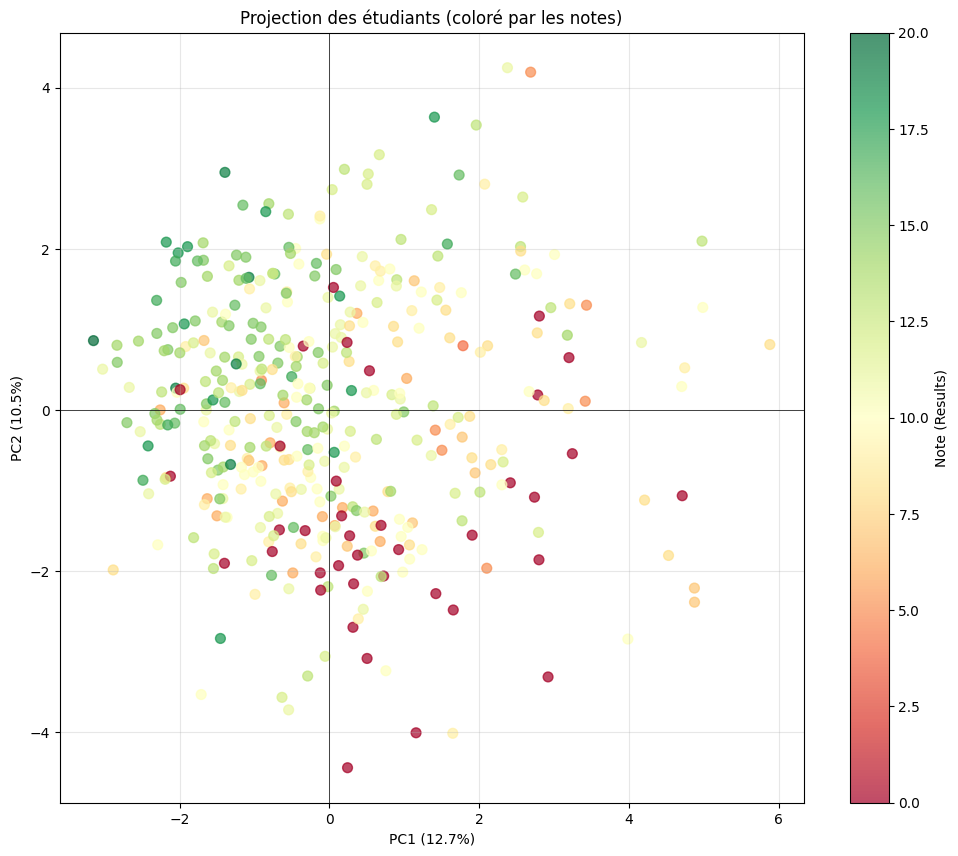

In [ ]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['Results'], 
                      cmap='RdYlGn', s=50, alpha=0.7)
plt.colorbar(scatter, label='Note (Results)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Projection des étudiants (coloré par les notes)')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

---
# II. Clustering
---

## 1. KMeans (3 clusters)

In [40]:
clustering_kmeans, kmeans = apply_kmeans(X_scaled, n_clusters=3)

print("Répartition :")
for i in range(3):
    print(f"Cluster {i}: {np.sum(clustering_kmeans == i)} étudiants")

Répartition :
Cluster 0: 168 étudiants
Cluster 1: 146 étudiants
Cluster 2: 81 étudiants


In [ ]:
print("Profil moyen de chaque cluster :")
for i in range(3):
    mask = clustering_kmeans == i
    cluster_data = data[mask]
    print(f"\nCluster {i} ({mask.sum()} étudiants):")
    print(f"  Note moyenne:    {cluster_data['Results'].mean():.1f}")
    print(f"  Temps étude:     {cluster_data['studytime'].mean():.1f}/4")
    print(f"  Échecs passés:   {cluster_data['failures'].mean():.2f}")
    print(f"  Alcool weekend:  {cluster_data['Walc'].mean():.1f}/5")
    print(f"  Sorties:         {cluster_data['goout'].mean():.1f}/5")

Profil moyen de chaque cluster :

Cluster 0 (168 étudiants):
  Note moyenne:    12.5
  Temps étude:     2.1/4
  Échecs passés:   0.05
  Alcool weekend:  2.0/5
  Sorties:         3.0/5

Cluster 1 (146 étudiants):
  Note moyenne:    8.8
  Temps étude:     2.3/4
  Échecs passés:   0.40
  Alcool weekend:  1.8/5
  Sorties:         2.8/5

Cluster 2 (81 étudiants):
  Note moyenne:    9.0
  Temps étude:     1.6/4
  Échecs passés:   0.80
  Alcool weekend:  3.9/5
  Sorties:         3.9/5


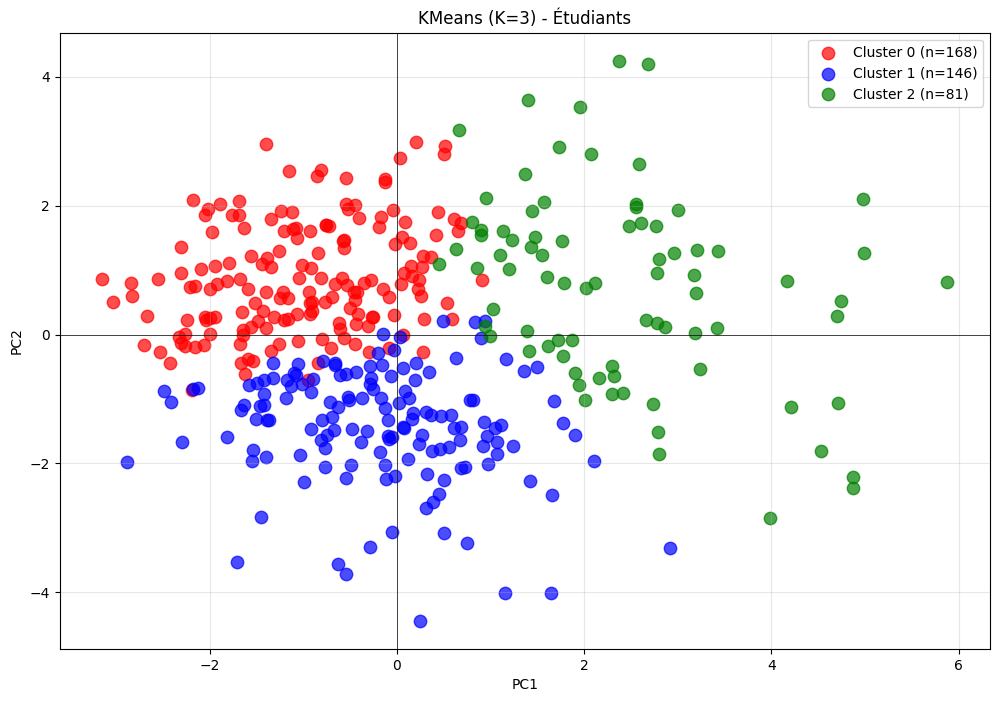

In [42]:
plot_clustering(X_pca, clustering_kmeans, labels, 'KMeans (K=3) - Étudiants', annotate=False)

## 2. AgglomerativeClustering

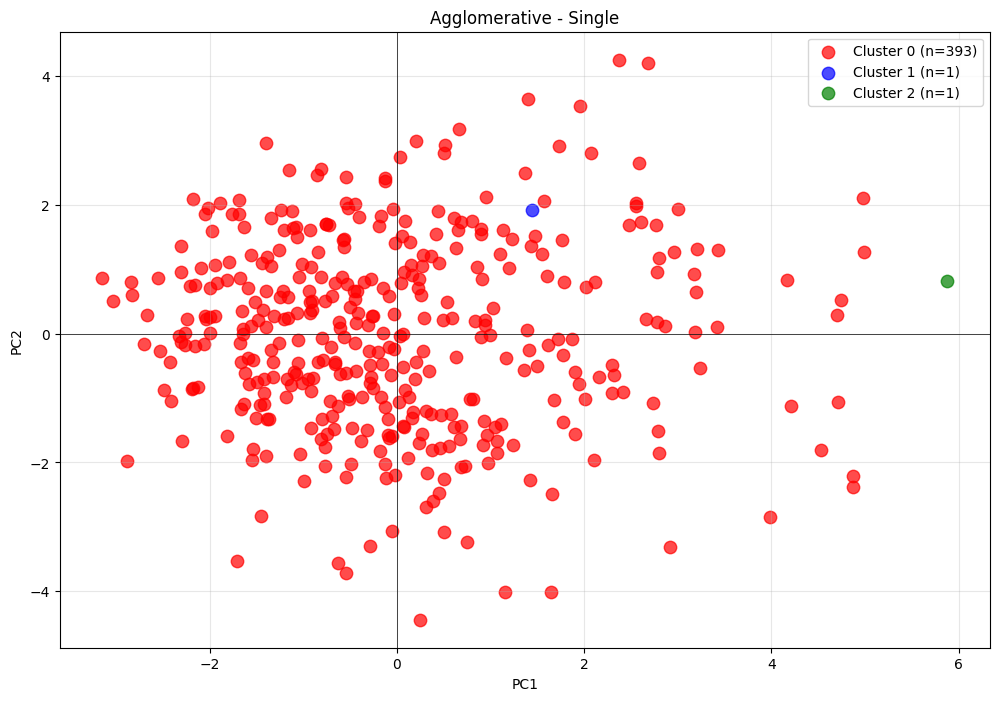

In [43]:
clustering_single = apply_agglomerative(X_scaled, n_clusters=3, linkage='single')
plot_clustering(X_pca, clustering_single, labels, 'Agglomerative - Single', annotate=False)

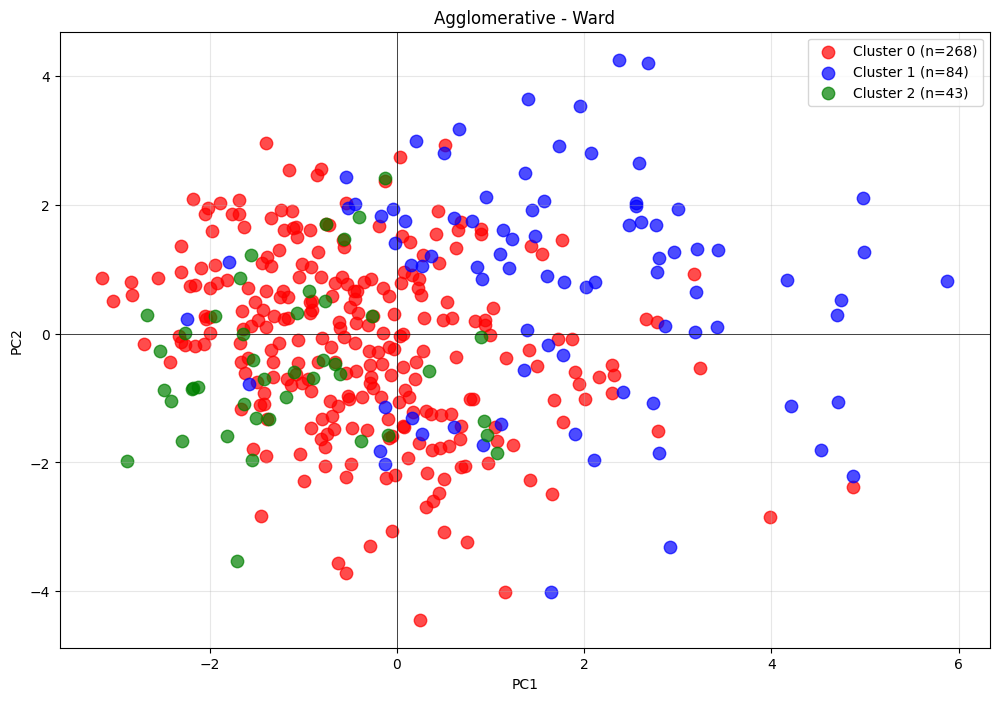

In [44]:
clustering_ward = apply_agglomerative(X_scaled, n_clusters=3, linkage='ward')
plot_clustering(X_pca, clustering_ward, labels, 'Agglomerative - Ward', annotate=False)

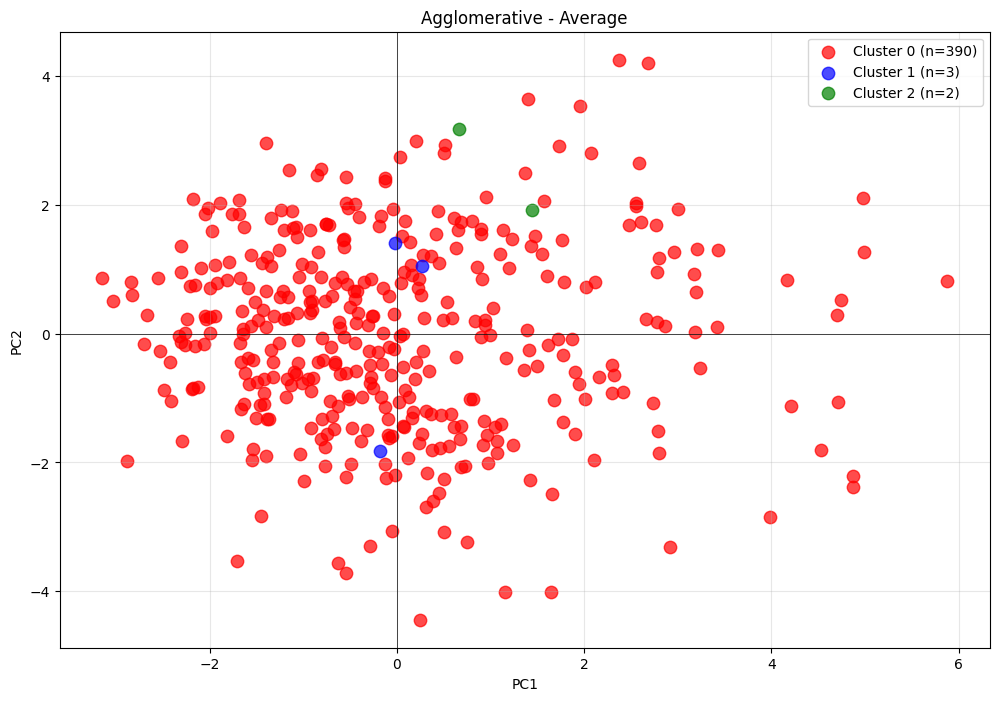

In [45]:
clustering_average = apply_agglomerative(X_scaled, n_clusters=3, linkage='average')
plot_clustering(X_pca, clustering_average, labels, 'Agglomerative - Average', annotate=False)

## 3. Détermination du nombre optimal (Silhouette)

In [46]:
scores, best_k = compute_silhouette_scores(X_scaled)

Indices Silhouette pour KMeans :
K=2: Silhouette = 0.1149
K=3: Silhouette = 0.0718
K=4: Silhouette = 0.0816
K=5: Silhouette = 0.0615
K=6: Silhouette = 0.0693
K=7: Silhouette = 0.0666
K=8: Silhouette = 0.0561
K=9: Silhouette = 0.0583

Meilleure partition : K=2 (Silhouette = 0.1149)


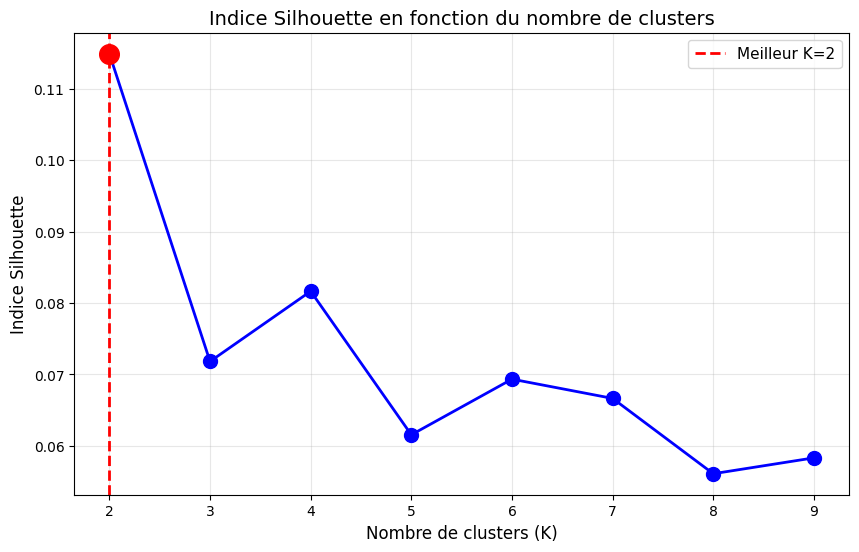

In [47]:
plot_silhouette_scores(scores)

## 4. Comparaison des méthodes

In [48]:
results = compare_methods(X_scaled, n_clusters=3)

Comparaison des méthodes pour 3 clusters :
KMeans          : Silhouette = 0.0718
Single          : Silhouette = 0.2488
Ward            : Silhouette = 0.0811
Average         : Silhouette = 0.2452
Hybride         : Silhouette = 0.0967

Meilleure méthode : Single (Silhouette = 0.2488)


## 5. Avantages et inconvénients

### Classification Hiérarchique (AgglomerativeClustering)

**Avantages :**
- Pas besoin de spécifier K à l'avance
- Produit une hiérarchie complète (dendrogramme)
- Résultats déterministes
- Peut découvrir des clusters de formes arbitraires (avec single linkage)

**Inconvénients :**
- Complexité O(n²) ou O(n³)
- Ne passe pas à l'échelle pour grands datasets
- Décisions de fusion irréversibles
- Single linkage : effet de chaînage

---

### Partitionnement (KMeans)

**Avantages :**
- Très rapide O(n×K×iterations)
- Scalable pour grands datasets
- Clusters compacts et bien séparés
- Simple à comprendre et implémenter

**Inconvénients :**
- Nécessite K à l'avance
- Sensible à l'initialisation (non-déterministe)
- Sensible aux outliers
- Assume des clusters sphériques

## 6. Approche Hybride

In [50]:
clustering_hyb, centers = clustering_hybride(X_scaled, n_clusters=3)
score_hyb = metrics.silhouette_score(X_scaled, clustering_hyb, metric='euclidean')
print(f"Approche Hybride - Silhouette : {score_hyb:.4f}")

Approche Hybride - Silhouette : 0.0967


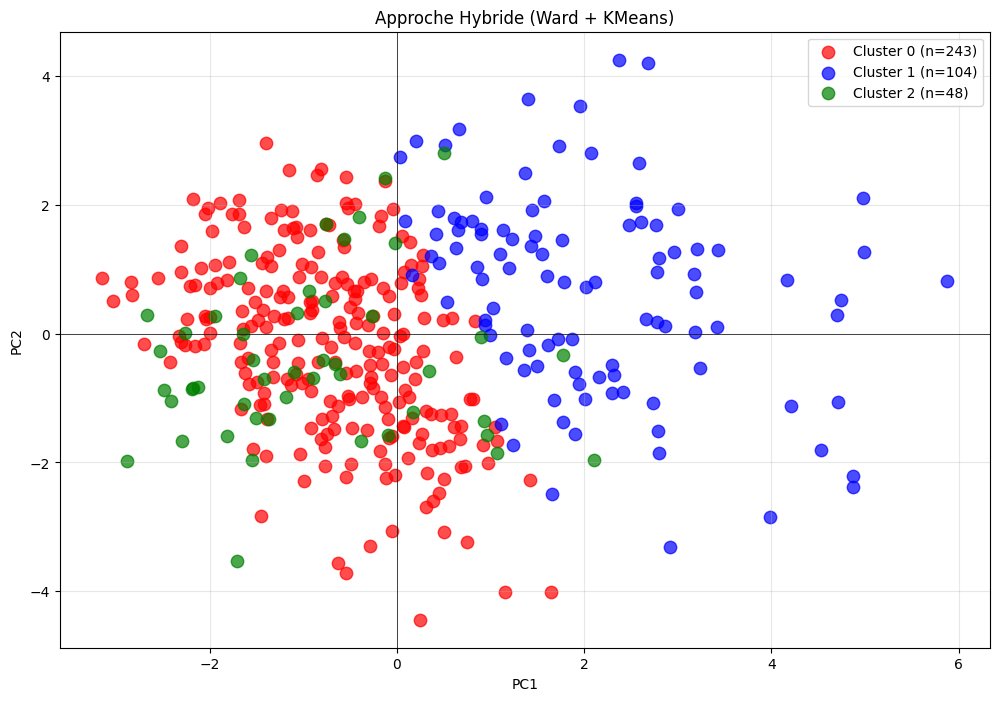

In [51]:
plot_clustering(X_pca, clustering_hyb, labels, 'Approche Hybride (Ward + KMeans)', annotate=False)

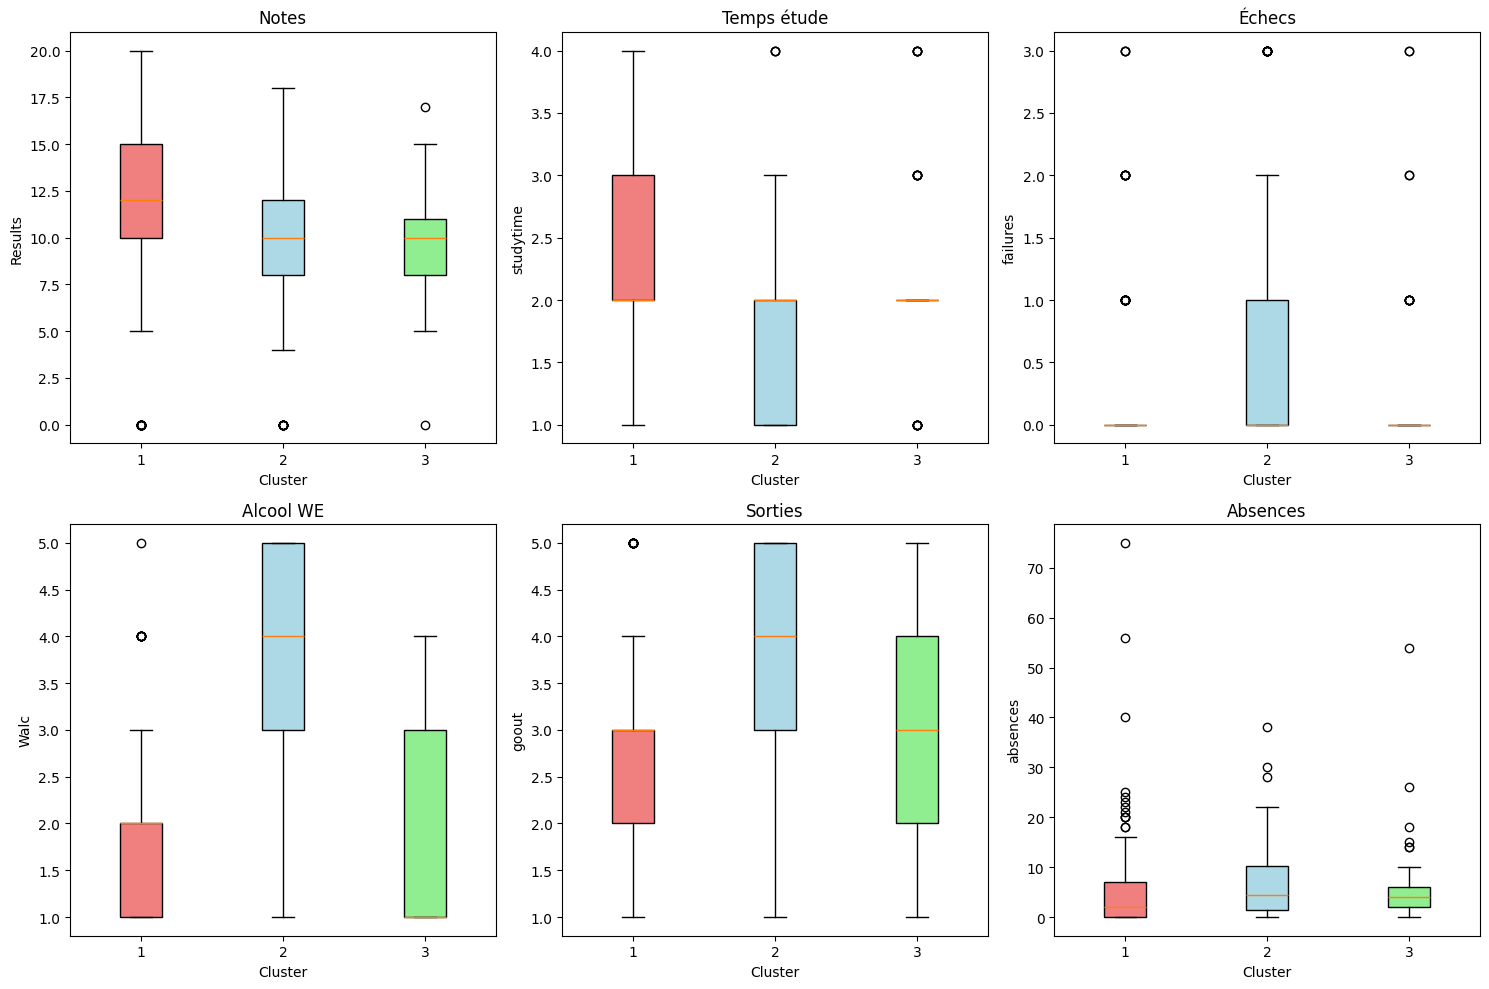

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
variables_to_plot = ['Results', 'studytime', 'failures', 'Walc', 'goout', 'absences']
titles = ['Notes', 'Temps étude', 'Échecs', 'Alcool WE', 'Sorties', 'Absences']

for idx, (var, title) in enumerate(zip(variables_to_plot, titles)):
    ax = axes[idx // 3, idx % 3]
    data_by_cluster = [data[clustering_hyb == i][var] for i in range(3)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True)
    colors_box = ['lightcoral', 'lightblue', 'lightgreen']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(var)
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
# Conclusion

1. **ACP** : Données hétérogènes, ~10 composantes pour 80% de variance
2. **Interprétation** : PC1 = comportement social, PC2 = milieu socio-économique
3. **Clustering** : Profils d'étudiants identifiables
   - Étudiants studieux avec bonnes notes
   - Étudiants moyens
   - Étudiants en difficulté
4. **Applications** : Identification précoce des étudiants à risque